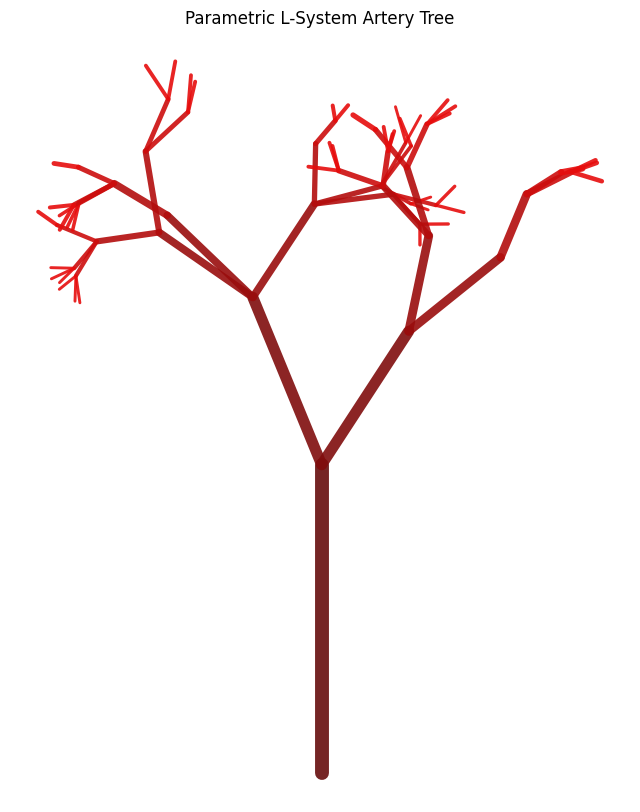

In [8]:
import math
import matplotlib.pyplot as plt
import random


def draw_parametric_tree(
    x,
    y,
    angle,
    length,
    depth,
    max_depth, #added to track color gradient
    branch_angle = 45,
    width = 6,
    shrink_width = 0.7,
    min_length = 1
):
      
    """
    Recursive stochastic L-system for simulation arterial branching.

    Each vessel segment produces:
    1. A forward-growing main vessel
    2. Multiple child branches with randomized angles and lengths

    Biological inspiration:
    - Arterial bifurcation patterns
    - Murray's Law for vessel radius scaling
    - Progressive vessel thinning

    Mathematical concepts:
    - Recursive fractal geometry
    - Trigonometric coordinate transformations
    - Stochastic parameter sampling
    """

    #Base case: stop recursion if max depth is reached or vessels become too small
    if depth == 0 or length < min_length:
        return

    #COLOR MODELING
    #Calculate a red intensity gradient. Smaller vessels (lower depth) appear darker (our design choice).
    #We want the color to change as we move from the trunk (max_depth) to the tips (depth=0)

    #(1-depth/max_depth) creates a value from 0.0 (trunk) to 1.0 (tips)
    #0.6*that value scales the range
    #0.4 is the base 'dark red' offset so the trunk isn't pitch black
    red_intensity=0.4+(0.6*(1-depth/max_depth)) 

    #vessel_color is defined as (Red, Green, Blue)
    #we keep Green and Blue very low (0.05) to ensure the vessel stays red
    vessel_color=(red_intensity, 0.05, 0.05)

    #GEOMETRY CALCULATION
    #The parent vessel extends forward before generating child branches
    #Scaling by 0.6 leaves remaining length available for recursive branching
    main_length = 0.6 * length 

    #Calculate new x & y coordinates for offset, then draw line between old and new coordinates
    #Find offset by converting polar displacement vector (length, angle) into Cartesian coordinates using trigonometric projection
    new_x = x + main_length * math.cos(math.radians(angle))
    new_y = y + main_length * math.sin(math.radians(angle))

    #Render the vessel segment
    plt.plot(
        [x, new_x],
        [y, new_y],
        linewidth=width,
        solid_capstyle="round",
        color=vessel_color,
        alpha=0.9
    )

    #STOCHASTIC BRANCHING
    #'num_branches' is chosen from a weighted distribution to favor 2-3 splits
    num_branches = random.choice([1,2,2,2,3,3]) # put more 2's and 3's so they're more likely

    #MURRAY'S IMPLEMENTATION
    #Murray's Law: r^3= r1^3 +r2^3+...
    #This relationship minimizes energy loss in biological circulation systems and preserves efficient blood flow.
    #Child vessel widths are scaled according to the number of bifurcations.
    
    if num_branches>1:
        #Assume equal child vessel radius at each split
        child_width=width/(num_branches**(1/3)) 
        
    else:
        #Slight tapering for a single continuation branch
        child_width=width*0.95

    #RECURSIVE BRANCH GENERATION
    #Each child vessel behaves like a smaller version of the parent vessel, creating a self-similar fractal branching structure
    for num in range(num_branches):

        #apply random variation to the angle and length to simulate organic growth
        # random angle
        random_angle = angle + random.uniform(random_angle_min,random_angle_max) # random number within a uniform distribution
        
        # random branch length
        random_length = length*random.uniform(random_length_min,random_length_max)

        #Recursive branching call
        draw_parametric_tree(
            x=new_x,
            y=new_y,
            angle=random_angle,
            length=random_length,
            depth=depth - 1,
            max_depth=max_depth,
            branch_angle=branch_angle,
            width=child_width, #using Murray's law width
            shrink_width=shrink_width,
            min_length=min_length
        )


# -----------------------------
# Execution
# -----------------------------

plt.figure(figsize=(8, 10))

#User-defined parameters for the stochastic model
random_angle_min=float(input("Lower bound for child angle change (-60 default): ") or -60)
random_angle_max=float(input("Upper bound for child angle change (60 default): ") or 60)
random_length_min=float(input("Lower bound for child branch length change (0.5 default): ") or 0.5)
random_length_max=float(input("Upper bound for child branch length change (0.75 default): ") or 0.75)
input_depth=float(input("Depth (6 default): ") or 6)

#Initialize the root of the arterial tree
draw_parametric_tree(
    x=0,
    y=0,
    angle=90,
    length=100,
    depth=input_depth, # example depth in paper was 4, but we increased it
    max_depth=input_depth, #set max_depth to our starting depth
    branch_angle=45,
    width=10, 
    shrink_width=0.82,
    min_length=1.5
)

plt.axis("equal")
plt.axis("off")
plt.title("Parametric L-System Artery Tree")
plt.show()